<a href="https://colab.research.google.com/github/anvi-rohra19/Data-Analyst-Portfolio/blob/main/Aerofit_Case.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Buisness Case > Aerofit** > Aerofit is a premium fitness equipment brand offering innovative and reliable workout solutions. It combines performance, durability, and sleek design for home and commercial gyms.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Observation on the data: Shape, datatypes of the attributes, identifying missing values.**

In [ ]:
af = pd.read_csv("aerofit_treadmill.csv")
af

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47
...,...,...,...,...,...,...,...,...,...
175,KP781,40,Male,21,Single,6,5,83416,200
176,KP781,42,Male,18,Single,5,4,89641,200
177,KP781,45,Male,16,Single,5,5,90886,160
178,KP781,47,Male,18,Partnered,4,5,104581,120


In [ ]:
af.ndim

2

In [ ]:
af.shape

(180, 9)

In [ ]:
af.dtypes

,0
Product,object
Age,int64
Gender,object
Education,int64
MaritalStatus,object
Usage,int64
Fitness,int64
Income,int64
Miles,int64


In [ ]:
af.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [ ]:
af.isnull().sum()

,0
Product,0
Age,0
Gender,0
Education,0
MaritalStatus,0
Usage,0
Fitness,0
Income,0
Miles,0


In [ ]:
af["Age"].agg(["min","max"])

,Age
min,18
max,50


**Observations on above:**

1. Aerofit_Treadmill.csv is 2 Dimensional, having rows and columns, hence a DataFrame.
2. The dataset contains 180 rows and 9 columns.
The name of the columns in our dataset are : Product, Age, Gender, Education (in years), MaritalStatus, Usage, Fitness, Income (in $), Miles.
3. Few of these needed categorical and datetime conversion for proper analysis.
4. None of the column has a null value (NaN values).
5. The dataset shows that the youngest person who purchased a treadmill is 18 years old, while the oldest is 50.

**Statistical Summary**

In [ ]:
af.describe()

,Age,Education,Usage,Fitness,Income,Miles
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,28.788889,15.572222,3.455556,3.311111,53719.577778,103.194444
std,6.943498,1.617055,1.084797,0.958869,16506.684226,51.863605
min,18.000000,12.000000,2.000000,1.000000,29562.000000,21.000000
25%,24.000000,14.000000,3.000000,3.000000,44058.750000,66.000000
50%,26.000000,16.000000,3.000000,3.000000,50596.500000,94.000000
75%,33.000000,16.000000,4.000000,4.000000,58668.000000,114.750000
max,50.000000,21.000000,7.000000,5.000000,104581.000000,360.000000


**Outlier Summary**
1. **Age :** Mean > Median → 28.78 > 26 ; Hence, No major outliers, age distribution looks normal.
2. **Education :** Median is slightly higher than mean → 16 > 15.57; No significant outliers; distribution is fairly tight.
3. **Usage :** Mean > Median → 3.45 > 3; very mild Hence, No serious outliers.
4. **Fitness :** Mean and median are close → 3.31 > 3, hence No major outliers.
5. **Income :** Mean > Median → 53719.57 > 50596.50 and max is double the median (likely a few very wealthy customers) hence strong positive outlier.
6. **Miles :** Mean > Median → 103.19 > 94 ; Hence strong outliers.

**Problem Statement 1: Detecting Income Outliers in Treadmill Buyer Data**

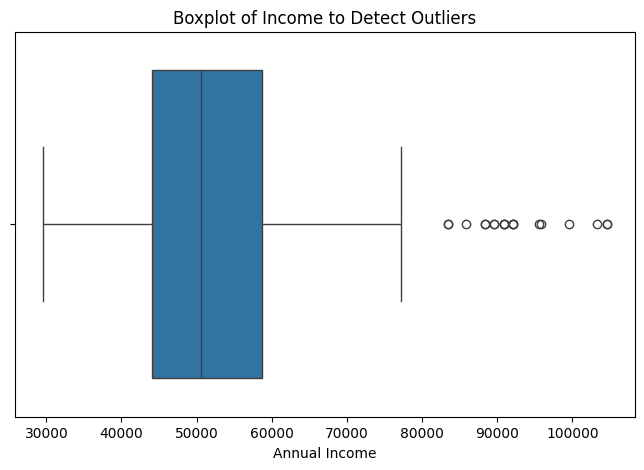

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=af['Income'])
plt.title("Boxplot of Income to Detect Outliers")
plt.xlabel("Annual Income")
plt.show()

In [ ]:
Q3 = np.percentile(af['Income'], 75)
Q1 = np.percentile(af['Income'], 25)
IQR = Q3 - Q1
IQR

np.float64(14609.25)

**Observation:**
1. Interquartile Range (IQR): The IQR came out as 14,609.
The IQR of ₹14,609.25 means that the middle 50% of customer incomes fall within a range of roughly ₹14.6k and as max and min are $104581 and $29562 hence an IQR of ₹14.6k is moderate.
2. Outliers : Several dots beyond ₹80,000 represent high-income outliers. These are buyers earning significantly more than the typical customer — up to over ₹1,00,000.
 → These outliers indicate: A. Wealthier customers
B. Potential segmentation group (e.g., premium segment)



**Problem Statement 2: Exploring the Influence of Customer Demographics and Economic features on Product Purchase**

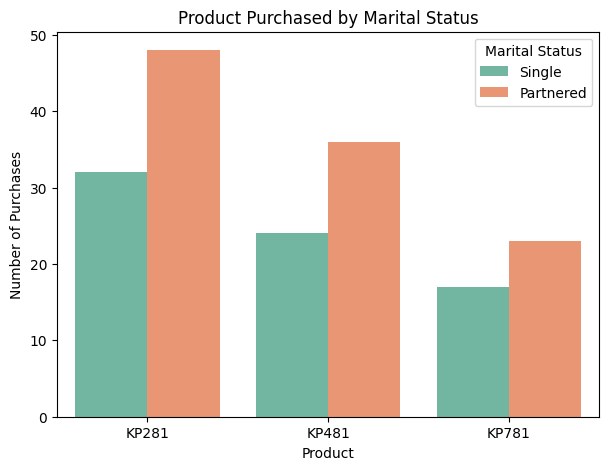

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Product', hue='MaritalStatus', data=af, palette='Set2')
plt.title('Product Purchased by Marital Status')
plt.xlabel('Product')
plt.ylabel('Number of Purchases')
plt.legend(title='Marital Status')
plt.show()

**Observation:**
1. Across all three products, Partnered individuals have purchased more treadmills than Single individuals.
2. Product KP281 indicates as a preferred model for couples or family use.
3. Product KP781 is the least purchased product by both Single and Partnered individuals.

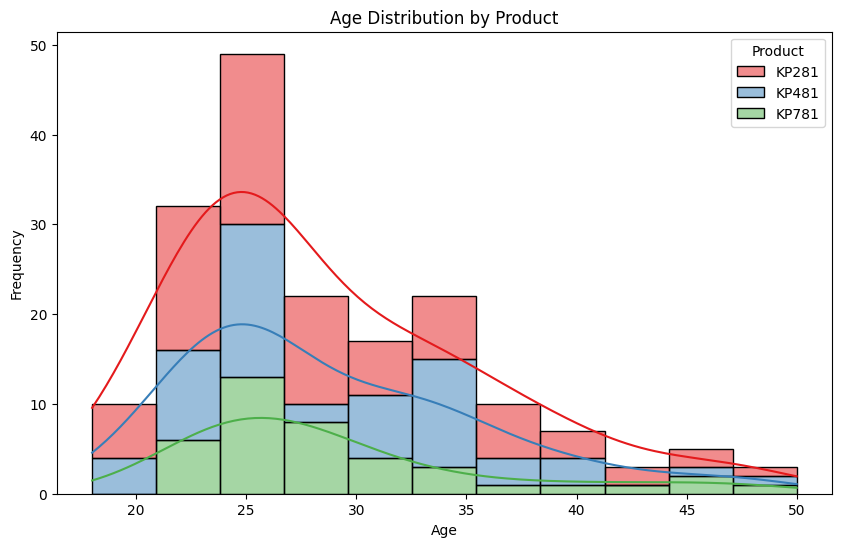

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=af, x='Age', hue='Product', kde=True, multiple='stack', palette='Set1')
plt.title('Age Distribution by Product')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

**Observations:**
1. KP281 seems most popular among younger customers as:
A. Sharp peak around age 24-26.
B. Large number of buyers between 20 and 30 years.
C. Very few customers above age 40 bought KP281.
2. KP481 looks evenly spread across 24-40 age group as:
A. Smoother and wider curve than KP281.
B. Substantial number of buyers between 25 and 40.
C. Slightly older target group compared to KP281.
3. KP781 is preferred by mid-age and older segment as:
A. Smaller peak but wider spread from 25 to 45+.
B. Fewer purchases, but mostly concentrated in older age brackets (30-50).

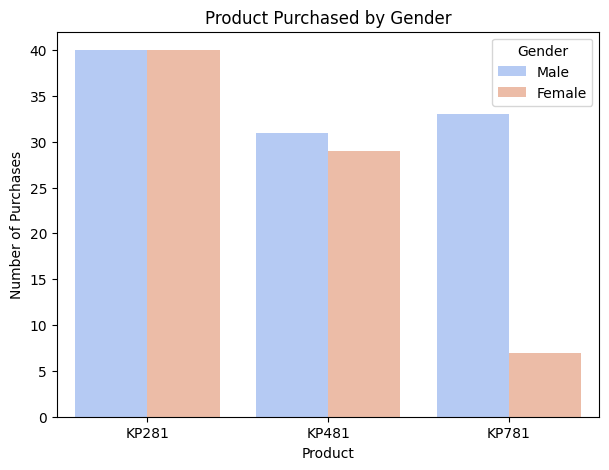

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Product', hue='Gender', data=af, palette='coolwarm')
plt.title('Product Purchased by Gender')
plt.xlabel('Product')
plt.ylabel('Number of Purchases')
plt.legend(title='Gender')
plt.show()

**Observations:**
1. KP281 seems to be equally purchased by both male and female.
2. KP481 has slightly more male buyers than female buyers.
3. KP781 has strong male(33) dominance as they outnumber female(7) buyers.

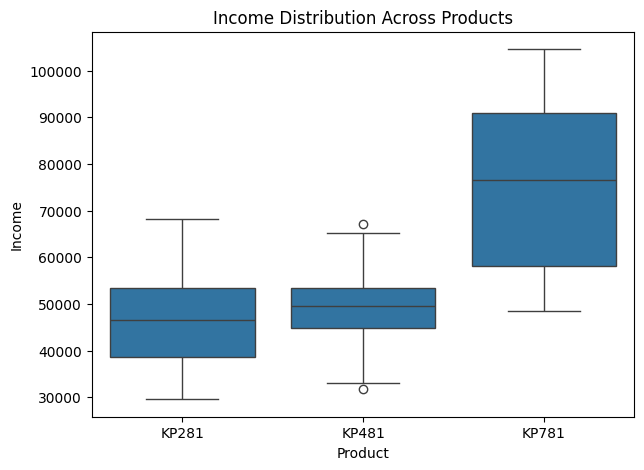

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='Product', y='Income', data=af)
plt.title('Income Distribution Across Products')
plt.xlabel('Product')
plt.ylabel('Income')
plt.show()

In [ ]:
af[af['Product'] == 'KP281']['Income'].median()

46617.0

In [ ]:
af[af['Product'] == 'KP481']['Income'].median()

49459.5

In [ ]:
af[af['Product'] == 'KP781']['Income'].median()

76568.5

In [ ]:
KP281_data = af[af['Product'] == 'KP281']['Income']
q1 = KP281_data.quantile(0.25)
q3 = KP281_data.quantile(0.75)
IQR = q3 - q1
IQR

np.float64(14781.0)

In [ ]:
KP481_data = af[af['Product'] == 'KP481']['Income']
q1 = KP481_data.quantile(0.25)
q3 = KP481_data.quantile(0.75)
IQR = q3 - q1
IQR

np.float64(8527.5)

In [ ]:
KP781_data = af[af['Product'] == 'KP781']['Income']
q1 = KP781_data.quantile(0.25)
q3 = KP781_data.quantile(0.75)
IQR = q3 - q1
IQR

np.float64(32681.25)

**Observations:**
1. KP281 seems to be a budget friendly model as :
Median income: $46617, IQR: $14781
Lower whisker extends to ~$30,000; upper to ~$69,000

2. For KP481, 50% of the customers have an income between $Q1 and $Q3, with an IQR of $8,527.50, showing a relatively tight income band among buyers.

3. KP781 looks like a premium segment as :
Median income: $76568.5, IQR: $32681.25
Whiskers and outliers extend up to ~$105,000


**Problem Statement 3: What percentage of customers purchased each product?**

In [ ]:
product_counts = pd.crosstab(index=af['Product'], columns='count')
product_counts['percentage'] = round((product_counts['count'] / product_counts['count'].sum()) * 100, 2)
product_counts

col_0,count,percentage
Product,,
KP281,80,44.44
KP481,60,33.33
KP781,40,22.22


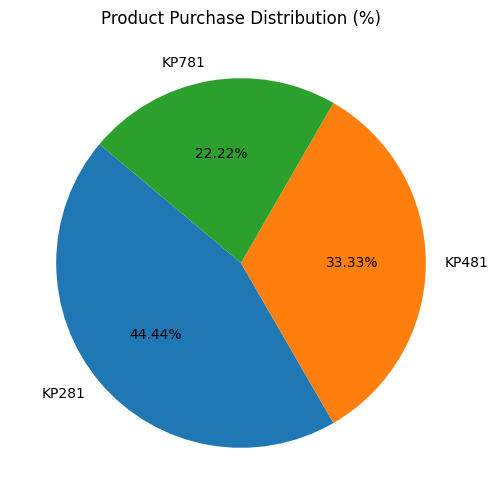

In [ ]:
labels = product_counts.index.tolist()
counts = product_counts['count'].tolist()

plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%.2f%%', startangle=140)
plt.title('Product Purchase Distribution (%)')
plt.show()

**Observations:**
1. KP281 - Nearly half of the customers (44.44%) purchased this model indicating top performing model maybe due to affordability.
2. KP481 - Chosen by 33.33% of customers making it a moderate product, with moderate price and features.
3. KP781 - Only 22.22% of customers purchased this model maybe due to higher price.

**Problem Statement 4 : What is the likelihood (i.e., marginal probability) that a customer is male or single, regardless of the product purchased?**

In [ ]:
total_customers = len(af)
male_count = (af['Gender'] == 'Male').sum()
single_count = (af['MaritalStatus'] == 'Single').sum()
both_male_and_single = ((af['Gender'] == 'Male') & (af['MaritalStatus'] == 'Single')).sum()
prob_male_or_single = (male_count + single_count - both_male_and_single) / total_customers
print(f"Probability of Male OR Single: {round(prob_male_or_single * 100, 2)}%")

Probability of Male OR Single: 74.44%


**Observations:**
Approximately 74.44% of customers are either male or single.
It shows a large portion of the customer base falls into at least one of these categories. This makes them an important segment for marketing and personalization strategies.

**Problem Statement 5: Is there a strong relationship between income and treadmill usage?**

In [ ]:
correlation_income_usage = af['Income'].corr(af['Usage'])
print("Correlation between Income and Usage:", round(correlation_income_usage, 2))

Correlation between Income and Usage: 0.52


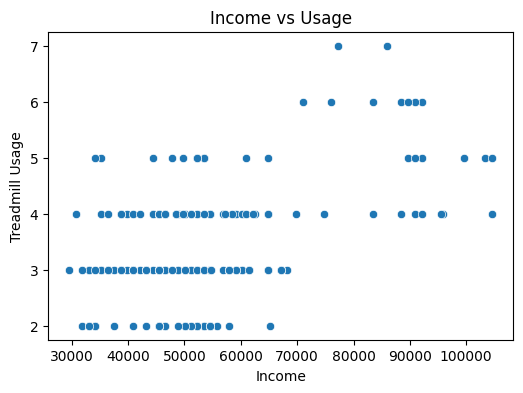

In [ ]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Income', y='Usage', data=af)
plt.title('Income vs Usage')
plt.xlabel('Income')
plt.ylabel('Treadmill Usage')
plt.show()

**Observations :**
1. People with both low and high incomes show similar usage levels (Usage values range mainly from 2 to 6).
2. This means that income is not a significant factor in determining how often a person uses the treadmill.

**Problem Statement 5 : Do younger people travel more miles on average?**

In [ ]:
correlation_age_miles = af['Age'].corr(af['Miles'])
print("Correlation between Age and Miles:", round(correlation_age_miles, 2))

Correlation between Age and Miles: 0.04


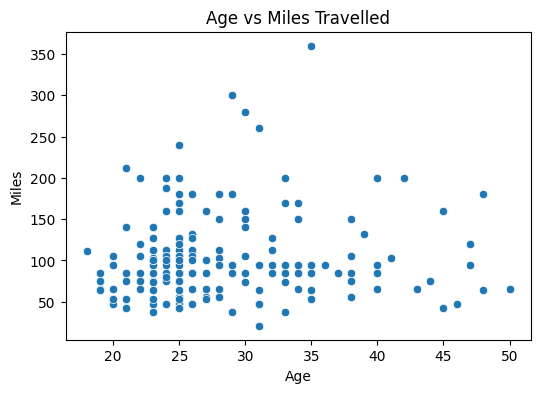

In [ ]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Age', y='Miles', data=af)
plt.title('Age vs Miles Travelled')
plt.xlabel('Age')
plt.ylabel('Miles')
plt.show()

**Observations :**
1. Younger age group (18-30) shows a higher concentration of users and a wider spread of miles traveled (ranging from ~30 to over 350 miles).
2. As age increases beyond 35, the number of data points decreases, and the miles travelled generally stay below 150.
3. Younger users tend to travel more miles on the treadmill than older users.

**Problem Statement 6 : Identify any strong correlations among key numerical features such as income, age, usage frequency, fitness level, and miles travelled?**

In [ ]:
correlation_matrix = af[['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']].corr()
correlation_matrix

,Age,Education,Usage,Fitness,Income,Miles
Age,1.000000,0.280496,0.015064,0.061105,0.513414,0.036618
Education,0.280496,1.000000,0.395155,0.410581,0.625827,0.307284
Usage,0.015064,0.395155,1.000000,0.668606,0.519537,0.759130
Fitness,0.061105,0.410581,0.668606,1.000000,0.535005,0.785702
Income,0.513414,0.625827,0.519537,0.535005,1.000000,0.543473
Miles,0.036618,0.307284,0.759130,0.785702,0.543473,1.000000


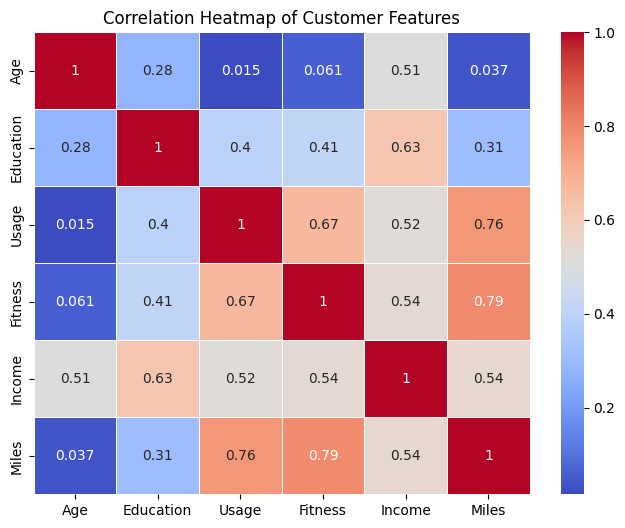

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Customer Features")
plt.show()

**Observations :**
1. Customers with higher fitness levels tend to travel more miles on the treadmill.
2. Meanwhile, Income shows moderate correlation with Usage, Fitness, and Education, indicating that socioeconomic factors do influence engagement.
3. Age, however, appears to have little influence on how customers use or benefit from the treadmill.

**Problem Statement 7 : What is the probability that a customer is partnered, given that they have purchased the KP781 treadmill?**

In [ ]:
KP781_customers = af[af['Product'] == 'KP781']
partnered_KP781 = KP781_customers[KP781_customers['MaritalStatus'] == 'Partnered']
prob_partnered_given_KP781 = len(partnered_KP781) / len(KP781_customers)
print(f"P(Partnered | KP781) = {round(prob_partnered_given_KP781 * 100, 2)}%")

P(Partnered | KP781) = 57.5%


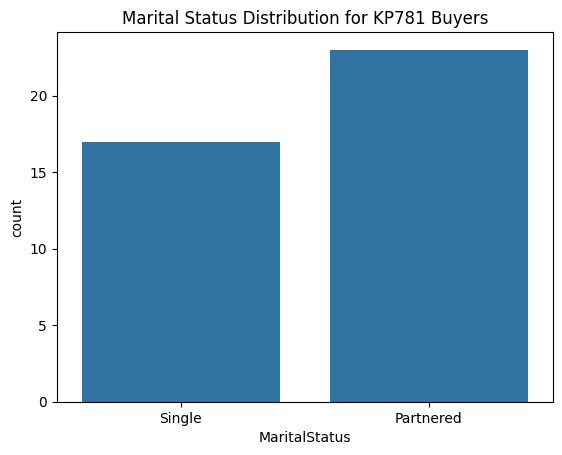

In [ ]:
sns.countplot(data=af[af['Product'] == 'KP781'], x='MaritalStatus')
plt.title("Marital Status Distribution for KP781 Buyers")
plt.show()

**Observations :** The conditional probability P(Partnered | KP781) = 57.5% indicates that a majority of customers (over half) who purchased the KP781 treadmill are partnered.
This suggests that the KP781 model may appeal more to partnered individuals than to singles.

**Problem Statement 8 : What is the probability that a customer earns more than $70,000, given that they purchased the KP781 model?**

In [ ]:
KP781_Customers = af[af['Product'] == 'KP781']
high_income_KP781 = KP781_Customers[KP781_Customers['Income'] > 70000]
prob_income_above_70k_given_KP781 = len(high_income_KP781) / len(KP781_Customers)
print(f"P(Income > 70000 | Product = KP781) = {round(prob_income_above_70k_given_KP781 * 100, 2)}%")

P(Income > 70000 | Product = KP781) = 57.5%


**Observations :** Around 57.5% of KP781 buyers earn more than $70,000.
This shows that a majority—but not an overwhelming majority—of KP781 customers fall into the higher-income segment.

**Business Insights**
1. Over 57% of KP781 buyers earn more than ₹70,000.
2. Indicates that KP781 is more popular among upper-income segments.
3. Although the majority are high earners, 42.5% of buyers earn ≤ ₹70,000, showing the model has cross-segment appeal.
4. It may be perceived as a "value-for-money premium" option.
5. Income Is a Partial Driver for Product Choice
6. Income seems to influence product preference (KP781), but other factors (e.g., fitness goals, marital status, age) may also play a role.

**Recommendations**
1. Highlight premium features like durability, advanced tracking, incline modes, etc.
2. Use the tagline: “Performance that fits your lifestyle — and your budget.”
3. Target high-income customers with digital ads focusing on:
-> Premium lifestyle
-> Long-term durability
4. Target middle-income customers with:
-> Easy EMI options
-> Fitness benefits for the whole family
5. Create marketing personas like:
-> “Aspiring Fit Families” (mid-income, Partnered)
-> “High-Income Solo Achievers” (single, upper-income)
6. Since higher-income customers are already spending more:
-> Offer bundles: treadmill + smartwatch or fitness mat.
-> Introduce loyalty perks for KP781 buyers.